# OHE

In [44]:
# Models cannot directly understand words or labels like "Red", "Blue", "Green"
# Encoding converts these categories into numbers so the model can process them

# Important note:
# Already numeric features → no encoding needed
# Categorical features (text/labels) → must be encoded

# In short:
# Encoding is only needed for non-numeric data to make it usable for ML models.

In [45]:
# One-Hot Encoding (OHE) – Sparse Matrix & Overfitting

# Sparse Matrix:
# OHE creates a separate column for each category, so most entries are zeros.

# Disadvantage: Uses lots of memory and can slow down computation for high-cardinality features.

# Overfitting Risk:
# Many OHE columns + small dataset → model may memorize specific category patterns.

# Leads to high variance: good on training, poor on new data.

# In short:
# OHE → creates sparse data and may cause overfitting if the dataset is small or categories are many.

# So; if u have may caegorical features then avoid using OHE.

In [46]:
# Sparse Matrix: A matrix mostly filled with zeros.
# Why it happens: OHE creates a separate column for each category.
# Example: 100 categories → 100 columns → most entries = 0

# Disadvantage:
# Consumes lots of memory for large categorical features
# Slows down computation in ML models

# In short:
# OHE → creates a sparse matrix with mostly zeros → memory and performance issues for high-cardinality features.

# Cardinality Features are those features with a large number of unique categories/values, e.g., ZIP codes, product IDs.

# So; Do not use OHE when you have a Feature with HUGE number of Categories within it.

In [47]:
# Use OHE (One-Hot-Encoding) for categorical features with a small number of unique categories (low-cardinality) to convert them into numeric form for ML models.

In [48]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [49]:
df = pd.DataFrame({
    "color":['red','blue','green','green','red','blue']
})

In [50]:
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [51]:
# fit part → The encoder looks at your data and remembers all the unique categories.
# Example: Red, Blue, Green
# transform part → The encoder changes the categories into numbers using one-hot encoding.
# It makes one column per category
# Puts 1 if the row has that category, else 0

# fit_transform() learns all categories and changes them into 0s and 1s in one step.

In [52]:
# Create an instance of OHE-:
encoder = OneHotEncoder()
# perform fit and then transform-:
encoder.fit_transform(df[['color']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (6, 3)>

In [53]:
# **`fit_transform()` (short explanation):**
# > It **learns the encoding rules** from the data (`fit`) and **applies the transformation** in one step (`transform`).
# ---

# ### In your example:
# ```python
# encoder.fit_transform(df[['color']]).toarray()
# ```

# 1. **`fit`** → Finds all unique categories in `color` (e.g., Red, Blue, Green)
# 2. **`transform`** → Converts each category into **one-hot encoded numeric array**
# 3. **`toarray()`** → Converts sparse matrix to a regular NumPy array

# **In short:**
# > Learns categories and converts them to numeric format in **one step**.

In [54]:
# One-Hot Encoder (OHE) requires a 2D input → a DataFrame or 2D array, not a simple list.
# List / Series (1D) → ❌ won’t work
# DataFrame / 2D array (rows × columns) → ✅ works perfectly
# Simple rule:
# Always pass df[['column']] or X shaped (n_samples, 1) for OHE.
encoded= encoder.fit_transform(df[['color']]).toarray()

In [55]:
encoded

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [56]:
encoder.get_feature_names_out()

array(['color_blue', 'color_green', 'color_red'], dtype=object)

In [57]:
import pandas as pd
encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [58]:
encoded_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [59]:
# For any NEW data-:
encoder.transform([['blue']]).toarray()

c:\Users\Omkar Raut\Desktop\DataSceince\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [60]:
# Here’s a **final concise note** combining both answers for commenting in code or saving:

# ---
# ## `fit()`, `transform()`, and `fit_transform()` in One-Hot Encoding
# * **`fit()`** → Learns the rules from the data (e.g., all unique categories).
#   * Does **not transform** the data.
#   * Example: Learns categories `Red, Blue, Green`

# * **`transform()`** → Applies the learned rules to convert data into numeric/encoded form.

#   * Requires `fit()` first.
#   * Cannot handle **new/unseen categories** by default → raises an error

# * **`fit_transform()`** → Does **fit + transform** in one step

# ### Handling new categories in test data

# ```python
# encoder = OneHotEncoder(handle_unknown='ignore')
# encoder.fit(train_df[['color']])
# encoder.transform(test_df[['color']])  # new/unseen categories → all zeros
# ```

# **Use case:**

# * Training data → `fit_transform()`
# * Test data → `transform()` (or with `handle_unknown='ignore'` to handle new categories)

# **In short:**
# > `fit()` = learn rules, `transform()` = apply rules, `fit_transform()` = learn + apply together.
# > New categories in `transform()` cause errors unless `handle_unknown='ignore'` is used.


In [61]:
# If handle_unknown='ignore' is used:
# transform() will not raise an error for new/unseen categories.
# Any new category will be represented as all zeros in the one-hot encoded array.

In [62]:
pd.concat([df,encoded_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [63]:
import seaborn as sns
df_tip = sns.load_dataset('tips')
df_tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [64]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
sex_arr = encoder.fit_transform(df_tip[["sex"]]).toarray()

In [65]:
encoder.get_feature_names_out()

array(['sex_Female', 'sex_Male'], dtype=object)

In [66]:
sex_tip = pd.DataFrame(sex_arr,columns=encoder.get_feature_names_out())

In [67]:
sex_tip

,sex_Female,sex_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
239,0.0,1.0
240,1.0,0.0
241,0.0,1.0
242,0.0,1.0


In [68]:
# Always pass 2D data to fit_transform(), not a list containing a Series.

In [69]:
smoker_arr = encoder.fit_transform(df_tip[["smoker"]]).toarray()
smoker_tip = pd.DataFrame(smoker_arr,columns=encoder.get_feature_names_out())
day_arr = encoder.fit_transform(df_tip[["day"]]).toarray()
day_tip = pd.DataFrame(day_arr,columns=encoder.get_feature_names_out())
time_arr = encoder.fit_transform(df_tip[["time"]]).toarray()
time_tip = pd.DataFrame(time_arr,columns=encoder.get_feature_names_out())

In [70]:
df_tip.drop("sex",axis=1,inplace=True)
df_tip.drop("smoker",axis=1,inplace=True)
df_tip.drop("day",axis=1,inplace=True)
df_tip.drop("time",axis=1,inplace=True)

In [71]:
pd.concat([df_tip,sex_tip,day_tip,smoker_tip,day_tip,time_tip],axis=1)

,total_bill,tip,size,sex_Female,sex_Male,day_Fri,day_Sat,day_Sun,day_Thur,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,10.34,1.66,3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,21.01,3.50,3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,23.68,3.31,2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,24.59,3.61,4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,3,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
240,27.18,2.00,2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
241,22.67,2.00,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
242,17.82,1.75,2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Label Encoding

In [72]:
df

,color
0,red
1,blue
2,green
3,green
4,red
5,blue


In [73]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder = LabelEncoder()

In [74]:
lbl_encoder.fit_transform(df[['color']])

c:\Users\Omkar Raut\Desktop\DataSceince\venv1\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2, 0])

In [75]:
lbl_encoder.transform([['red']])

c:\Users\Omkar Raut\Desktop\DataSceince\venv1\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [76]:
lbl_encoder.transform([['blue']])

c:\Users\Omkar Raut\Desktop\DataSceince\venv1\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

In [77]:
lbl_encoder.transform([['green']])

c:\Users\Omkar Raut\Desktop\DataSceince\venv1\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([1])

In [ ]:
# ## **Label Encoding – Summary**

# **Definition:**
# > Converts **categorical labels into numeric form** so ML models can process them.

# ### **How it works:**

# * Assigns a unique number to each category.
# * Example:

# | Color | Encoded |
# | ----- | ------- |
# | Red   | 0       |
# | Blue  | 1       |
# | Green | 2       |


# ### **Use Cases:**

# 1. **Ordinal Data (categories with order)** ✅

#    * Label Encoding **works**, but numbers **must respect natural order**.
#    * Example of wrong automatic encoding:

# ```python
# from sklearn.preprocessing import LabelEncoder
# data = ['Small', 'Medium', 'Large']
# le = LabelEncoder()
# le.fit_transform(data)
# # Output: Large=0, Medium=1, Small=2 → WRONG order!
# ```

# * **Safe way (manual mapping):**

# ```python
# mapping = {'Small': 0, 'Medium': 1, 'Large': 2}
# encoded = [mapping[x] for x in data]
# # Correct order preserved
# ```

# 2. **Nominal Data (categories without order)** ❌

#    * Label Encoding **should not be used** → numbers imply false order.
#    * Use **One-Hot Encoding (OHE)** instead.

# ### **Important Notes:**

# * `fit()` → learns categories.
# * `transform()` → converts categories to numbers using learned mapping.
# * `fit_transform()` → learns and converts in **one step**.
# * **Unseen categories** during `transform()` → error unless `handle_unknown='ignore'` is used.

# ### **Common Issues:**

# 1. **Ordinal data:** Alphabetical encoding may **break natural order** → must map manually.
# 2. **Nominal data:** Numbers imply **order that doesn’t exist** → can cause wrong model behavior.

# **In short:**
# > Label Encoding = safe for **ordinal** if **order is preserved manually**, risky for **nominal**, always check **category order** before encoding.

In [ ]:
# ## **Label Encoding – Key Points**

# ### 1️⃣ Why **Label Encoding should not be used on nominal data**

# * **Nominal data** = categories with **no natural order** (e.g., Red, Blue, Green, City names).
# * If you apply Label Encoding:

# ```
# Red → 0, Blue → 1, Green → 2
# ```

# * The model may **assume an order or magnitude** between the numbers (e.g., 2 > 1 → Green > Blue), which **doesn’t exist**.
# * This can **mislead the model** and reduce accuracy.

# ✅ **Correct approach:** Use **One-Hot Encoding** for nominal features.


# ### 2️⃣ Ordinal vs Nominal
# * **Ordinal:** Label Encoding **can be used**, but **numbers must respect the order** (manual mapping recommended).
# * **Nominal:** Label Encoding **should never be used** → use One-Hot Encoding.

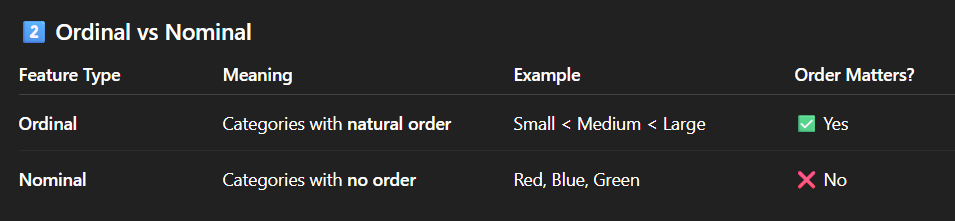

### Ordinal Encoding

In [80]:
from sklearn.preprocessing import OrdinalEncoder
# Create simple DataFrame with Ordinal Variable-:
df = pd.DataFrame({
    "size": ['small', 'medium', 'large', 'medium', 'small', 'large']
})

In [81]:
df1 =  pd.DataFrame(data= ['small', 'medium', 'large', 'medium', 'small', 'large'],columns=['size'])

In [82]:
df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [83]:
df1

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [99]:
# Create an INSTANCE of Ordinal Encoder and then fit_transform-:
# Order of items in the list of "categories" matter here.So; please write them in CORRECT ORDER IN "categories" parameter.
encoder = OrdinalEncoder(categories=[['small','medium','large']])

In [100]:
encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [103]:
encoder.transform([['small']])

c:\Users\Omkar Raut\Desktop\DataSceince\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[0.]])